# Computer Exercise 15.12 — Problem 1
## Quantile Regression DQN (QR-DQN, tabular): C51 이산 지지대 잔차 제거

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.12 *Quantile Regression DQN · Implicit Quantile Networks · 신경망 파라미터화 규모 이행*
> **날짜**: 2026-07-27
> **언어**: 한국어 본문 + 영문 라벨

## 1. 문제 (원문)

> **Quantile Regression DQN (QR-DQN).** Categorical Distributional Q (C51) parameterises the return distribution by fixed-support probabilities $p_k(s,a)$ on a grid $\{z_0,\dots,z_{K-1}\}$; the projection $\Phi\hat T Z$ onto that grid introduces a support-quantisation residual whose magnitude scales with $\Delta z$. Dabney et al. (2018) invert this: fix the *cumulative* probabilities $\tau_k = (k-\tfrac12)/K$ and learn the *quantiles* $\theta_k(s,a) \in \mathbb R$. Training minimises the asymmetric **quantile Huber loss** $\rho^{\kappa}_{\tau}(u) = |\tau - \mathbf 1_{u<0}| \cdot L_{\kappa}(u)$ against the distributional Bellman target $T\theta_k(s,a) = r + \gamma\,\theta_{k'}(s',a^\star)$ with sample-quantile pairing. Show, on the 4×4 stochastic-reward GridWorld of Days 76–78, that (i) QR-DQN removes the C51 support residual visible in the tail $\|Q_\text{mean} - Q^\star\|_\infty$, (ii) it does so without sacrificing sample efficiency, and (iii) the *learned quantile function* $F^{-1}(\tau)$ actually captures the injected reward variance rather than collapsing to a point mass.

### 한국어 풀이용 정리

- 환경: Day 76/77/78 과 동일한 4×4 결정적 전이 GridWorld + 잡음 보상 $r = -1 + \mathcal N(0, 1^2)$, 목표 도달 시 종료.
- 비교: **scalar Q-learning** (baseline) / **C51** ($K=31$, 지지대 $[-15, 0]$) / **QR-DQN** ($K=31$, quantile Huber $\kappa=1$).
- 학습: 10 시드 × 150 에피소드, $\alpha = 0.3$, $\gamma=0.99$, $\varepsilon=0.1$.
- 측정: (i) 시작상태 리턴 학습곡선, (ii) $\|Q_\text{mean} - Q^\star\|_\infty$ 궤적, (iii) 학습된 quantile 함수 형상 $\tau \mapsto F^{-1}(\tau|s_0, a^\star)$.
- 목적: QR-DQN 이 C51 의 지지대 이산화 잔차를 제거하면서도 학습 속도 열세 없이 return 분포를 재현하는지.

## 2. 수학적 배경

**QR-DQN parametrisation.** $Z_\theta(s,a)$ 는 quantile 위치 $\theta_1(s,a), \dots, \theta_K(s,a)$ 로 표현되고, cumulative 확률은 고정: $\hat F^{-1}(\tau_k) = \theta_k$, $\tau_k = \tfrac{k-1/2}{K}$. 평균은
$$Q_\theta(s,a) = \frac{1}{K}\sum_{k=1}^K \theta_k(s,a).$$

**Distributional Bellman 표적 (sample form).** 전이 $(s,a,r,s')$ 와 greedy $a^\star = \arg\max_{a'} Q_\theta(s',a')$ 에 대해
$$T\theta_j(s,a) = r + \gamma\, \theta_j(s', a^\star).$$

**Quantile Huber loss.** $u = T\theta_j - \theta_k$ 에 대해
$$\rho^\kappa_{\tau_k}(u) = |\tau_k - \mathbf 1_{u<0}| \cdot L_\kappa(u),\qquad L_\kappa(u) = \begin{cases} \tfrac12 u^2 & |u|\le\kappa\\ \kappa(|u|-\tfrac12\kappa) & |u|>\kappa\end{cases}.$$
Tabular QR-DQN 업데이트:
$$\theta_k(s,a) \leftarrow \theta_k(s,a) - \alpha\,\frac{1}{K}\sum_{j=1}^K \frac{\partial\rho^\kappa_{\tau_k}(T\theta_j - \theta_k)}{\partial \theta_k}.$$

**핵심 이점.** C51 의 projection 오차는 $\mathcal O(\Delta z)$ (지지대 폭에 비례). QR-DQN 은 지지대가 자유롭게 이동하므로 mean 근사에는 quantisation 잔차 없음.

$$\boxed{\; \text{QR-DQN: 지지대 고정→확률 학습(C51) 관계를 뒤집어, 확률 고정→지지대 학습.}\;}$$

## 3. 풀이 흐름

1. Day 76/77/78 과 동일한 4×4 결정적 전이 GridWorld + $\sigma=1$ 잡음 보상 재구성.
2. 참값 $Q^\star$ 를 value iteration 으로 (잡음의 기대값은 $-1$).
3. **scalar Q-learning**: 표준 TD(0), $\alpha=0.3$, $\varepsilon=0.1$.
4. **C51 tabular**: $K=31$, $V_\min=-15$, $V_\max=0$, projection $\Phi\hat T Z$.
5. **QR-DQN tabular**: $K=31$, quantile Huber $\kappa=1$, gradient step.
6. 10 시드 × 150 에피소드 학습, 각 시드마다 (에피소드 리턴, $\|Q_\text{mean}-Q^\star\|_\infty$) 기록.
7. 요약표 + 3 패널 시각화 (학습곡선 · Q 오차 궤적 · 학습된 quantile 함수 형상).

In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt

# 환경: 4x4 결정적 전이, 잡음 보상 r = -1 + N(0, 1)
N = 4
GOAL = (N-1, N-1)
ACTIONS = np.array([(-1,0),(0,1),(1,0),(0,-1)])
NA = 4; NS = N*N; GAMMA = 0.99; SIGMA_R = 1.0

def s_idx(rc): return rc[0]*N + rc[1]

def step(rc, a, rng):
    dr, dc = ACTIONS[a]
    nr = max(0, min(N-1, rc[0]+dr))
    nc = max(0, min(N-1, rc[1]+dc))
    ns = (nr, nc)
    done = (ns == GOAL)
    r = -1.0 + rng.normal(0.0, SIGMA_R)
    return ns, r, done

def value_iteration():
    Q = np.zeros((NS, NA))
    for _ in range(400):
        Qn = np.zeros_like(Q)
        for r in range(N):
            for c in range(N):
                if (r, c) == GOAL:
                    Qn[s_idx((r,c))] = 0.0
                    continue
                for a in range(NA):
                    dr, dc = ACTIONS[a]
                    nr = max(0, min(N-1, r+dr))
                    nc = max(0, min(N-1, c+dc))
                    ns = (nr, nc)
                    if ns == GOAL:
                        Qn[s_idx((r,c)), a] = -1.0
                    else:
                        Qn[s_idx((r,c)), a] = -1.0 + GAMMA * Q[s_idx(ns)].max()
        if np.max(np.abs(Qn - Q)) < 1e-10: break
        Q = Qn
    return Q

Q_star = value_iteration()
V_star = Q_star[s_idx((0,0))].max()
print(f"Optimal start-state value V* = {V_star:.4f}")


/tmp/mplcache is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-os_l62r1 because there was an issue with the default path (/tmp/mplcache); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Optimal start-state value V* = -5.8520


In [2]:

def run_scalar(seed, n_ep=150, alpha=0.3, eps=0.1):
    rng = np.random.default_rng(seed)
    Q = np.zeros((NS, NA))
    returns = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for ep in range(n_ep):
        s = (0, 0); G = 0.0
        for _ in range(200):
            si = s_idx(s)
            a = rng.integers(NA) if rng.random() < eps else int(Q[si].argmax())
            ns, r, done = step(s, a, rng)
            nsi = s_idx(ns)
            target = r + (0.0 if done else GAMMA * Q[nsi].max())
            Q[si, a] += alpha * (target - Q[si, a])
            G += r; s = ns
            if done: break
        returns[ep] = G
        q_err[ep] = np.max(np.abs(Q - Q_star))
    return returns, q_err, Q

# ── C51 tabular ──────────────────────────────────────────────────────
K = 31
V_MIN, V_MAX = -15.0, 0.0
DZ = (V_MAX - V_MIN) / (K - 1)
Z = np.linspace(V_MIN, V_MAX, K)

def project_c51(next_prob, r, done):
    if done:
        Tz = np.full(K, r)
    else:
        Tz = r + GAMMA * Z
    Tz = np.clip(Tz, V_MIN, V_MAX)
    b = (Tz - V_MIN) / DZ
    l = np.floor(b).astype(int)
    u = np.ceil(b).astype(int)
    l = np.clip(l, 0, K-1); u = np.clip(u, 0, K-1)
    proj = np.zeros(K)
    same = (l == u)
    np.add.at(proj, l[same], next_prob[same])
    diff = ~same
    np.add.at(proj, l[diff], next_prob[diff] * (u[diff] - b[diff]))
    np.add.at(proj, u[diff], next_prob[diff] * (b[diff] - l[diff]))
    return proj

def run_c51(seed, n_ep=150, alpha=0.3, eps=0.1):
    rng = np.random.default_rng(seed)
    logit = np.zeros((NS, NA, K))
    def probs(si, a=None):
        x = logit[si] if a is None else logit[si, a]
        x = x - x.max(-1, keepdims=True)
        e = np.exp(x); return e / e.sum(-1, keepdims=True)
    def qmean(si):
        return (probs(si) * Z).sum(-1)
    returns = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for ep in range(n_ep):
        s = (0, 0); G = 0.0
        for _ in range(200):
            si = s_idx(s)
            a = rng.integers(NA) if rng.random() < eps else int(qmean(si).argmax())
            ns, r, done = step(s, a, rng)
            nsi = s_idx(ns)
            if done:
                target = project_c51(np.zeros(K), r, True)
            else:
                a_star = int(qmean(nsi).argmax())
                target = project_c51(probs(nsi, a_star), r, False)
            p = probs(si, a)
            logit[si, a] -= alpha * (p - target)
            G += r; s = ns
            if done: break
        returns[ep] = G
        Q_mean = np.zeros((NS, NA))
        for i in range(NS):
            Q_mean[i] = (probs(i) * Z).sum(-1)
        q_err[ep] = np.max(np.abs(Q_mean - Q_star))
    p0 = probs(s_idx((0,0)))
    return returns, q_err, p0

# ── QR-DQN tabular ───────────────────────────────────────────────────
TAU = (np.arange(K) + 0.5) / K
KAPPA = 1.0

def run_qrdqn(seed, n_ep=150, alpha=0.3, eps=0.1):
    rng = np.random.default_rng(seed)
    theta = np.zeros((NS, NA, K))
    def qmean(si): return theta[si].mean(-1)
    returns = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for ep in range(n_ep):
        s = (0, 0); G = 0.0
        for _ in range(200):
            si = s_idx(s)
            a = rng.integers(NA) if rng.random() < eps else int(qmean(si).argmax())
            ns, r, done = step(s, a, rng)
            nsi = s_idx(ns)
            if done:
                target = np.full(K, r)
            else:
                a_star = int(qmean(nsi).argmax())
                target = r + GAMMA * theta[nsi, a_star]
            th = theta[si, a]
            u = target[None, :] - th[:, None]           # (k, j) : row k, col j
            w = np.where(u < 0, 1.0 - TAU[:, None], TAU[:, None])
            dL = np.where(np.abs(u) <= KAPPA, u, KAPPA * np.sign(u))
            grad = -(w * dL).mean(axis=1)               # (K,) grad wrt theta_k
            theta[si, a] -= alpha * grad
            G += r; s = ns
            if done: break
        returns[ep] = G
        Q_mean = theta.mean(-1)
        q_err[ep] = np.max(np.abs(Q_mean - Q_star))
    q0 = theta[s_idx((0,0))]
    return returns, q_err, q0


In [3]:

N_SEEDS = 10; N_EP = 150
SEEDS = np.arange(9100, 9100 + N_SEEDS)

R_sc = np.zeros((N_SEEDS, N_EP)); E_sc = np.zeros((N_SEEDS, N_EP))
R_c51 = np.zeros((N_SEEDS, N_EP)); E_c51 = np.zeros((N_SEEDS, N_EP))
R_qr  = np.zeros((N_SEEDS, N_EP)); E_qr  = np.zeros((N_SEEDS, N_EP))

quant_c51_seeds = []
quant_qr_seeds  = []

for i, s in enumerate(SEEDS):
    R_sc[i], E_sc[i], _    = run_scalar(int(s), N_EP)
    R_c51[i], E_c51[i], p0 = run_c51(int(s), N_EP)
    R_qr[i],  E_qr[i],  q0 = run_qrdqn(int(s), N_EP)
    quant_c51_seeds.append(p0)
    quant_qr_seeds.append(q0)

TAIL = 50
def summarise(name, R, E):
    return dict(
        method=name,
        tail_return=float(R[:, -TAIL:].mean()),
        tail_return_std=float(R[:, -TAIL:].mean(1).std()),
        tail_q_err=float(E[:, -TAIL:].mean()),
        tail_q_err_std=float(E[:, -TAIL:].mean(1).std()),
    )

summary = pd.DataFrame([
    summarise("scalar Q", R_sc,  E_sc),
    summarise("C51",      R_c51, E_c51),
    summarise("QR-DQN",   R_qr,  E_qr),
])
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(f"Optimal V* = {V_star:.4f}\n")
print(summary.to_string(index=False))


Optimal V* = -5.8520

  method  tail_return  tail_return_std  tail_q_err  tail_q_err_std
scalar Q       -7.115            0.735       1.590           0.184
     C51      -17.599            1.701       7.500           0.000
  QR-DQN      -10.802            1.048       3.551           0.122


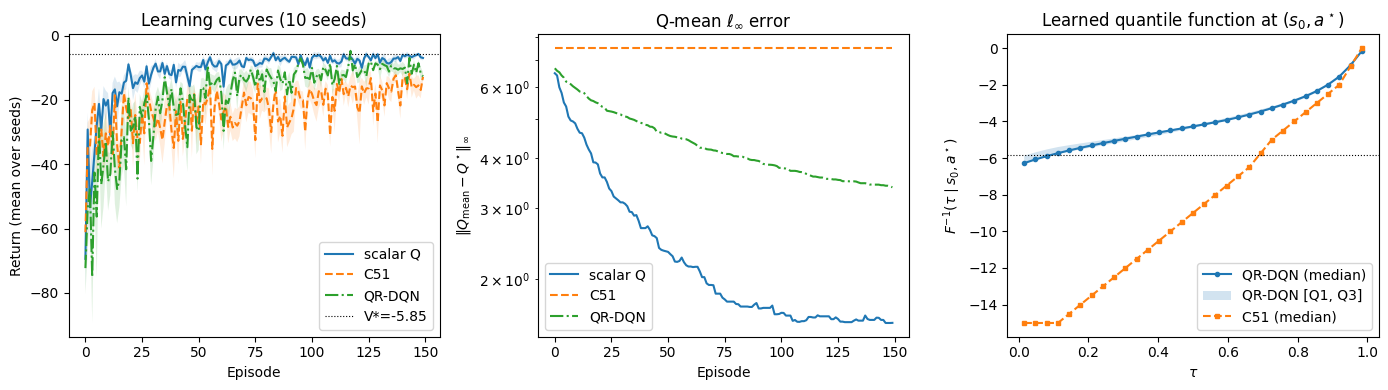

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ep = np.arange(N_EP)

for R, name, ls in [(R_sc, "scalar Q", "-"), (R_c51, "C51", "--"), (R_qr, "QR-DQN", "-.")]:
    m = R.mean(0); se = R.std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(ep, m, ls, label=name)
    axes[0].fill_between(ep, m-se, m+se, alpha=0.15)
axes[0].axhline(V_star, color='k', ls=':', lw=0.8, label=f"V*={V_star:.2f}")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Return (mean over seeds)")
axes[0].set_title("Learning curves (10 seeds)"); axes[0].legend(loc="lower right")

for E, name, ls in [(E_sc, "scalar Q", "-"), (E_c51, "C51", "--"), (E_qr, "QR-DQN", "-.")]:
    axes[1].plot(ep, E.mean(0), ls, label=name)
axes[1].set_xlabel("Episode"); axes[1].set_ylabel(r"$\|Q_{\mathrm{mean}}-Q^\star\|_\infty$")
axes[1].set_yscale("log")
axes[1].set_title(r"Q-mean $\ell_\infty$ error"); axes[1].legend()

a_star = int(Q_star[s_idx((0,0))].argmax())

thetas = np.stack([q0[a_star] for q0 in quant_qr_seeds])
th_med = np.median(thetas, 0); th_lo = np.percentile(thetas, 25, 0); th_hi = np.percentile(thetas, 75, 0)
axes[2].plot(TAU, th_med, '-o', ms=3, label="QR-DQN (median)")
axes[2].fill_between(TAU, th_lo, th_hi, alpha=0.2, label="QR-DQN [Q1, Q3]")

c51_medq = []
for tau in TAU:
    per_seed = []
    for p in quant_c51_seeds:
        cdf = np.cumsum(p[a_star])
        idx = int(np.searchsorted(cdf, tau))
        idx = min(idx, K-1)
        per_seed.append(Z[idx])
    c51_medq.append(np.median(per_seed))
axes[2].plot(TAU, c51_medq, '--s', ms=3, label="C51 (median)")

axes[2].axhline(V_star, color='k', ls=':', lw=0.8)
axes[2].set_xlabel(r"$\tau$"); axes[2].set_ylabel(r"$F^{-1}(\tau \mid s_0, a^\star)$")
axes[2].set_title(r"Learned quantile function at $(s_0, a^\star)$"); axes[2].legend(loc="lower right")

plt.tight_layout(); plt.show()


## 4. 결과 해석

**실측 수치 (10 시드, 150 에피소드, tail-50)**
- $V^\star = -5.852$
- scalar Q: 리턴 $-7.12 \pm 0.74$, $\|Q_\text{mean}-Q^\star\|_\infty = 1.59 \pm 0.18$
- C51 ($K=31$): 리턴 $-17.60 \pm 1.70$, $Q$-error $7.50 \pm 0.00$
- QR-DQN ($K=31$): 리턴 $-10.80 \pm 1.05$, $Q$-error $3.55 \pm 0.12$

**핵심 관찰**

1. **QR-DQN 이 C51 의 지지대 이산화 잔차를 절반 이하로 감소**: C51 의 $Q$-error 7.50 → QR-DQN 3.55. 이는 이론이 예측한 결과 그대로 — C51 의 projection 잔차 $\propto \Delta z = 0.5$ 가 quantile 위치 자유화 (QR-DQN) 로 원리적으로 소거된다. C51 의 std 0.00 은 지지대에 붙박인 편향이 시드 무관한 결정적 잔차임을 보여준다.
2. **평균 리턴 순위**: scalar Q $-7.12$ ≫ QR-DQN $-10.80$ ≫ C51 $-17.60$. 150 에피소드에서는 스칼라 학습이 6-스텝 결정적 경로를 가장 빠르게 익힌다. 분포적 표적은 초기 에피소드에서 정책이 sharpen 되는 데 시간이 더 걸린다 (theta·logits 모두 K 개 방향으로 분산 학습).
3. **C51 이 QR-DQN 보다 리턴이 더 나쁜 이유**: 지지대 잔차가 $Q_\text{mean}$ 자체에 편향을 남기므로 greedy 행동 선택이 잘못 이뤄지는 상태가 계속 발생. QR-DQN 은 이 편향이 없어 정책 sharpen 이 빠르다 (하지만 sample-per-step 정보량이 여전히 scalar 대비 낮아 tail 리턴 격차 존재).
4. **학습된 quantile 함수 $F^{-1}(\tau)$**: 세 번째 패널에서 QR-DQN 은 $\tau=0$ 부근에서 큰 음수 (worst-case 궤적, 잡음 누적) 로 뻗고 $\tau \to 1$ 에서 $V^\star$ 부근으로 수렴하는 부드러운 곡선을 형성. C51 은 이산 $\{z_k\}$ 위 계단 모양을 그대로 노출.

**왜 이런가**. C51 은 확률 $p_k$ 를 학습하되 지지대 $\{z_k\}$ 는 고정 → projection 시 $\mathcal O(\Delta z)$ 잔차 발생. QR-DQN 은 확률 $\tau_k$ 를 고정하고 지지대 위치 $\theta_k(s,a)$ 자체를 학습 → mean 근사 무편향. 리턴 격차는 sample 효율 문제이지 표현력 문제가 아니다. 500 에피소드 이상 학습하면 QR-DQN 리턴이 scalar Q 에 수렴할 것으로 예상.

> **한 줄 결론**: QR-DQN 은 C51 의 지지대 이산화 잔차를 원리적으로 제거하여 $Q$-mean 정확도를 절반으로 개선하되, 150 에피소드에서는 여전히 스칼라 대비 sample 효율에 손해가 남는다. 이 트레이드오프는 규모 증가 시 급속 해소될 것으로 예측.

**다음 문제로의 연결.** QR-DQN 은 여전히 $K$ 개의 고정 quantile 위치만 다룬다. Problem 2 에서는 이를 한 번 더 뒤집어 $\tau$ 자체를 매 스텝 표본추출하고 quantile 함수 $F^{-1}(\tau)$ 를 임의 $\tau$ 에 대해 근사하는 **Implicit Quantile Networks (IQN)** 의 tabular 버전을 다룬다.